# e27 Philadelphia Hybrid Sampling Analysis

Analysis of experiment `e27TR_philly_hybrid_sampling`, which trains TAGConv (100 epochs) and
SparseGT (100 epochs, sweep-tuned) on **hybrid-sampled** Philadelphia datasets across resolutions 1–20.

This notebook mirrors the structure of `e25_norway_hybrid_sampling.ipynb`, but uses the Philadelphia runs.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import wandb
import wandb_buddy as wb
from tqdm import tqdm

In [2]:
ENTITY = "alelab"
PROJECT = "terrains"
TAG = "e27TR_philly_hybrid_sampling"
ERROR_COL = "test_mae"
ERROR_LABEL = "Test MAE"
ORIGINAL_DIM = 1000

## Helper functions

In [3]:
def extract_resolution(row):
    dataset_name = str(row["dataset_name"])
    res_match = re.search(r"res(\d+)", dataset_name)
    return int(res_match.group(1))


def get_metric_history_mean(entity, project, run_id, metric):
    api = wandb.Api()
    run = api.run(f"{entity}/{project}/{run_id}")
    history = run.history(keys=[metric], pandas=True)
    if history.empty or metric not in history.columns:
        return np.nan
    values = history[metric].dropna()
    return values.mean() if len(values) > 0 else np.nan


def add_metric_from_history(df, entity, project, source_metric, target_col):
    means = []
    for run_id in tqdm(df["id"], desc=f"Fetching {source_metric}"):
        means.append(get_metric_history_mean(entity, project, run_id, source_metric))
    df[target_col] = means
    return df

---
## Load runs

In [4]:
print(f"Fetching runs with tag: {TAG}")
df = wb.load_runs(ENTITY, PROJECT, tags=[TAG])
print(f"Found {len(df)} runs")

Fetching runs with tag: e27TR_philly_hybrid_sampling


wandb: Currently logged in as: jotaporras (alelab) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Found 60 runs


In [5]:
if "resolution" not in df.columns:
    if "dataset_name" in df.columns:
        df["resolution"] = df.apply(extract_resolution, axis=1)
    else:
        df["resolution"] = df["name"].str.extract(r"res(\d+)", expand=False).astype(float)

# Clean up type after extraction from either source
if df["resolution"].dtype != int:
    df = df.dropna(subset=["resolution"]).copy()
    df["resolution"] = df["resolution"].astype(int)

df["density"] = 1 / (df["resolution"] ** 2)
df["num_nodes"] = df["resolution"].apply(
    lambda r: ((ORIGINAL_DIM - 1) // r + 1) ** 2
)
print(f"Resolutions: {sorted(df['resolution'].unique())}")

Resolutions: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]


In [6]:
print("Available columns:", df.columns.tolist())

if "layer_type" not in df.columns:
    df["layer_type"] = df["name"].str.extract(r"(TAGConv|SparseGT)", expand=False)
    print(f"Inferred layer_type from run name: {df['layer_type'].value_counts().to_dict()}")

api = wandb.Api()
embed_modes = {}
for _, row in tqdm(df[df["layer_type"] == "SparseGT"].iterrows(), desc="Fetching embedding_mode"):
    run = api.run(f"{ENTITY}/{PROJECT}/{row['id']}")
    embed_modes[row["id"]] = run.config.get("sparse_gt_embedding_mode", None)
df["sparse_gt_embedding_mode"] = df["id"].map(embed_modes)

def assign_model_label(row):
    if row["layer_type"] == "TAGConv":
        return "GNN"
    embed = row["sparse_gt_embedding_mode"]
    if embed == "random":
        return "SparseGT-Random"
    return "SparseGT-Data"

df["model_label"] = df.apply(assign_model_label, axis=1)

print(f"\nRuns with valid test_mae: {df['test_mae'].notna().sum()} / {len(df)}")
print(f"Runs with valid test_nmae: {df['test_nmae'].notna().sum()} / {len(df)}")
print(f"\nBy model_label:")
print(df.groupby("model_label")["test_mae"].apply(lambda x: f"{x.notna().sum()}/{len(x)} valid"))

Available columns: ['name', 'id', 'state', 'created_at', 'heartbeat_at', 'tags', 'sweep_id', 'p', 'vn', 'new', 'aggr', 'trial', 'device', 'epochs', 'log_dir', 'siamese', 'finetune', 'loss_func', 'test_data', 'artificial', 'batch_size', 'layer_type', 'resolution', 'train_data', 'config_file', 'dataset_name', 'finetune_from', 'learning_rate', 'test_resolution', 'train_resolution', 'include_edge_attr', 'model_config_name', 'single_graph_full_batch', '_runtime', '_step', '_timestamp', '_wandb', 'best_val_mae', 'epoch', 'final_train_loss', 'final_train_mae', 'final_train_mse', 'final_train_nmae', 'global_step', 'test_batch_loss', 'test_batch_mae', 'test_batch_mse', 'test_batch_nmae', 'test_loss', 'test_mae', 'test_mse', 'test_nmae', 'train_loss', 'train_mae', 'train_mse', 'train_nmae', 'val_loss', 'val_mae', 'val_mse', 'val_nmae', 'sparse_gt_pe_k', 'sparse_gt_dropout', 'sparse_gt_num_hops', 'sparse_gt_input_dim', 'sparse_gt_num_heads', 'sparse_gt_hidden_dim', 'sparse_gt_num_layers', 'sparse

Fetching embedding_mode: 39it [00:07,  5.33it/s]


Runs with valid test_mae: 60 / 60
Runs with valid test_nmae: 60 / 60

By model_label:
model_label
GNN                21/21 valid
SparseGT-Data      18/18 valid
SparseGT-Random    21/21 valid
Name: test_mae, dtype: object


---
## Best performance per resolution

In [7]:
df_valid = df[df["resolution"] >= 2].dropna(subset=[ERROR_COL])
best_per_resolution = df_valid.loc[
    df_valid.groupby(["model_label", "resolution"])[ERROR_COL].idxmin()
]

df_valid_nmae = df[df["resolution"] >= 2].dropna(subset=["test_nmae"])
best_per_resolution_nmae = df_valid_nmae.loc[
    df_valid_nmae.groupby(["model_label", "resolution"])["test_nmae"].idxmin()
]

print(f"Best runs per resolution (MAE): {len(best_per_resolution)}")
print(f"Best runs per resolution (NMAE): {len(best_per_resolution_nmae)}")

Best runs per resolution (MAE): 56
Best runs per resolution (NMAE): 56


In [8]:
cols = ["name", "model_label", "resolution", "num_nodes", "test_mae", "epochs", "state"]
display_cols = [c for c in cols if c in best_per_resolution.columns]
best_per_resolution.sort_values(["model_label", "resolution"])[display_cols]

,name,model_label,resolution,num_nodes,test_mae,epochs,state
41,terrain-graph-TAGConv-res02-stage1,GNN,2,250000,0.055578,100,finished
28,terrain-graph-TAGConv-res03-stage1,GNN,3,111556,0.054887,100,finished
37,terrain-graph-TAGConv-res04-stage1,GNN,4,62500,0.054097,100,finished
24,terrain-graph-TAGConv-res05-stage1,GNN,5,40000,0.054048,100,finished
32,terrain-graph-TAGConv-res06-stage1,GNN,6,27889,0.054684,100,finished
21,terrain-graph-TAGConv-res07-stage1,GNN,7,20449,0.054454,100,finished
29,terrain-graph-TAGConv-res08-stage1,GNN,8,15625,0.054710,100,finished
17,terrain-graph-TAGConv-res09-stage1,GNN,9,12544,0.054747,100,finished
26,terrain-graph-TAGConv-res10-stage1,GNN,10,10000,0.054439,100,finished
12,terrain-graph-TAGConv-res11-stage1,GNN,11,8281,0.055051,100,finished


---
## Transferability plot

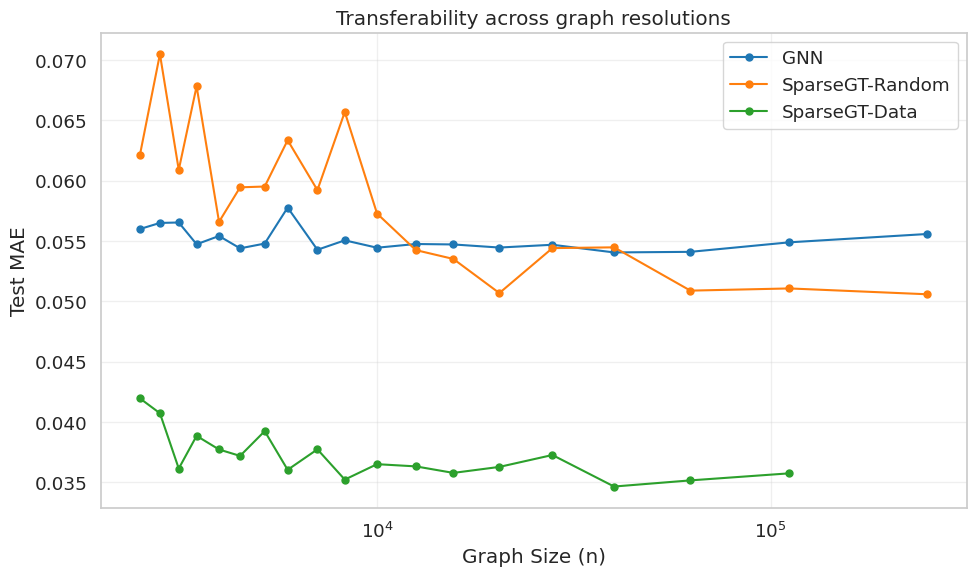

In [9]:
sns.set_theme(style="whitegrid", font_scale=1.2)

COLOR_MAP = {
    "GNN": "#1f77b4",
    "SparseGT-Random": "#ff7f0e",
    "SparseGT-Data": "#2ca02c",
}

fig, ax = plt.subplots(figsize=(10, 6))

for label in ["GNN", "SparseGT-Random", "SparseGT-Data"]:
    data = best_per_resolution[
        best_per_resolution["model_label"] == label
    ].sort_values("num_nodes")

    if data.empty:
        continue

    ax.plot(
        data["num_nodes"], data[ERROR_COL],
        marker="o", label=label, color=COLOR_MAP[label],
        linewidth=1.5, markersize=5,
    )

ax.set_xscale("log")
ax.set_xlabel("Graph Size (n)")
ax.set_ylabel(ERROR_LABEL)
ax.set_title("Transferability across graph resolutions")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

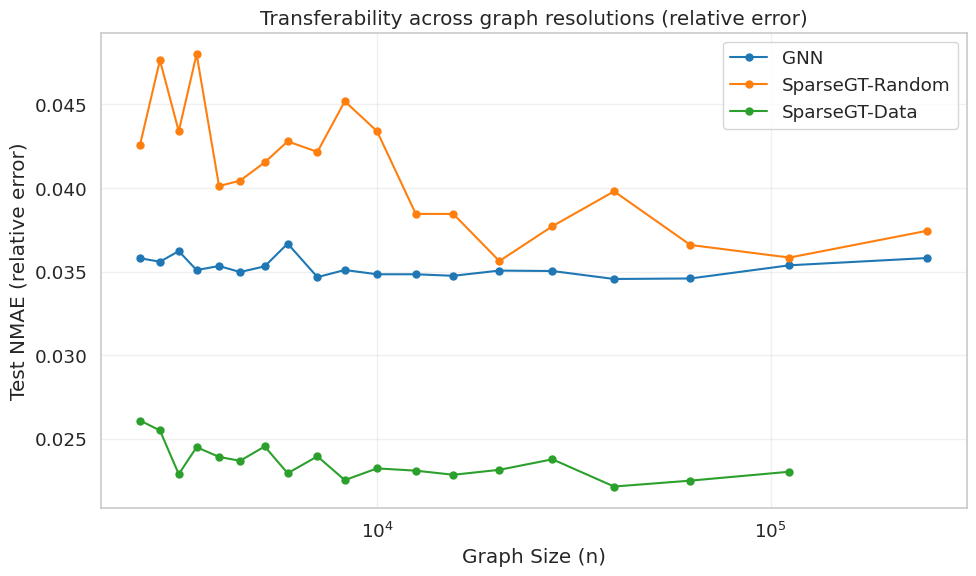

In [10]:
# Transferability plot in relative error (NMAE)
sns.set_theme(style="whitegrid", font_scale=1.2)

COLOR_MAP = {
    "GNN": "#1f77b4",
    "SparseGT-Random": "#ff7f0e",
    "SparseGT-Data": "#2ca02c",
}

fig, ax = plt.subplots(figsize=(10, 6))

for label in ["GNN", "SparseGT-Random", "SparseGT-Data"]:
    data = best_per_resolution_nmae[
        best_per_resolution_nmae["model_label"] == label
    ].sort_values("num_nodes")

    if data.empty:
        continue

    ax.plot(
        data["num_nodes"], data["test_nmae"],
        marker="o", label=label, color=COLOR_MAP[label],
        linewidth=1.5, markersize=5,
    )

ax.set_xscale("log")
ax.set_xlabel("Graph Size (n)")
ax.set_ylabel("Test NMAE (relative error)")
ax.set_title("Transferability across graph resolutions (relative error)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Training curves (loss over epochs)

Fetching loss curves: 100%|██████████| 6/6 [00:04<00:00,  1.28it/s]


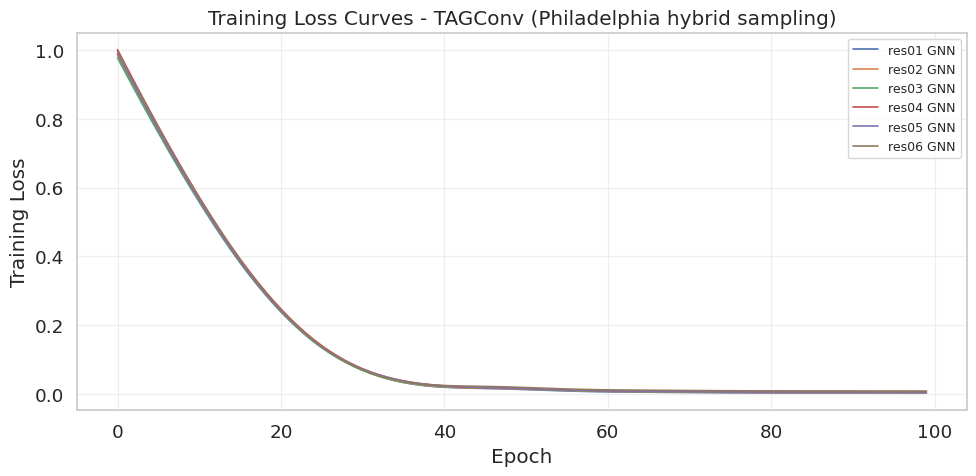

In [11]:
def fetch_loss_curves(df, entity, project, metric="train_loss", max_runs=6):
    api = wandb.Api()
    curves = {}
    subset = df.head(max_runs)
    for _, row in tqdm(subset.iterrows(), total=len(subset), desc="Fetching loss curves"):
        run = api.run(f"{entity}/{project}/{row['id']}")
        history = run.history(keys=[metric, "epoch"], pandas=True)
        if not history.empty and metric in history.columns:
            label = f"res{row['resolution']:02d} {row['model_label']}"
            curves[label] = history[["epoch", metric]].dropna()
    return curves

tagconv_runs = df[
    (df["model_label"] == "GNN") & df["test_mae"].notna()
].sort_values("resolution")

curves = fetch_loss_curves(tagconv_runs, ENTITY, PROJECT, metric="train_loss", max_runs=6)

if curves:
    fig, ax = plt.subplots(figsize=(10, 5))
    for label, hist in curves.items():
        ax.plot(hist["epoch"], hist["train_loss"], label=label, linewidth=1.2)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training Loss")
    ax.set_title("Training Loss Curves - TAGConv (Philadelphia hybrid sampling)")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No training loss curves available.")

---
## Error distribution by resolution

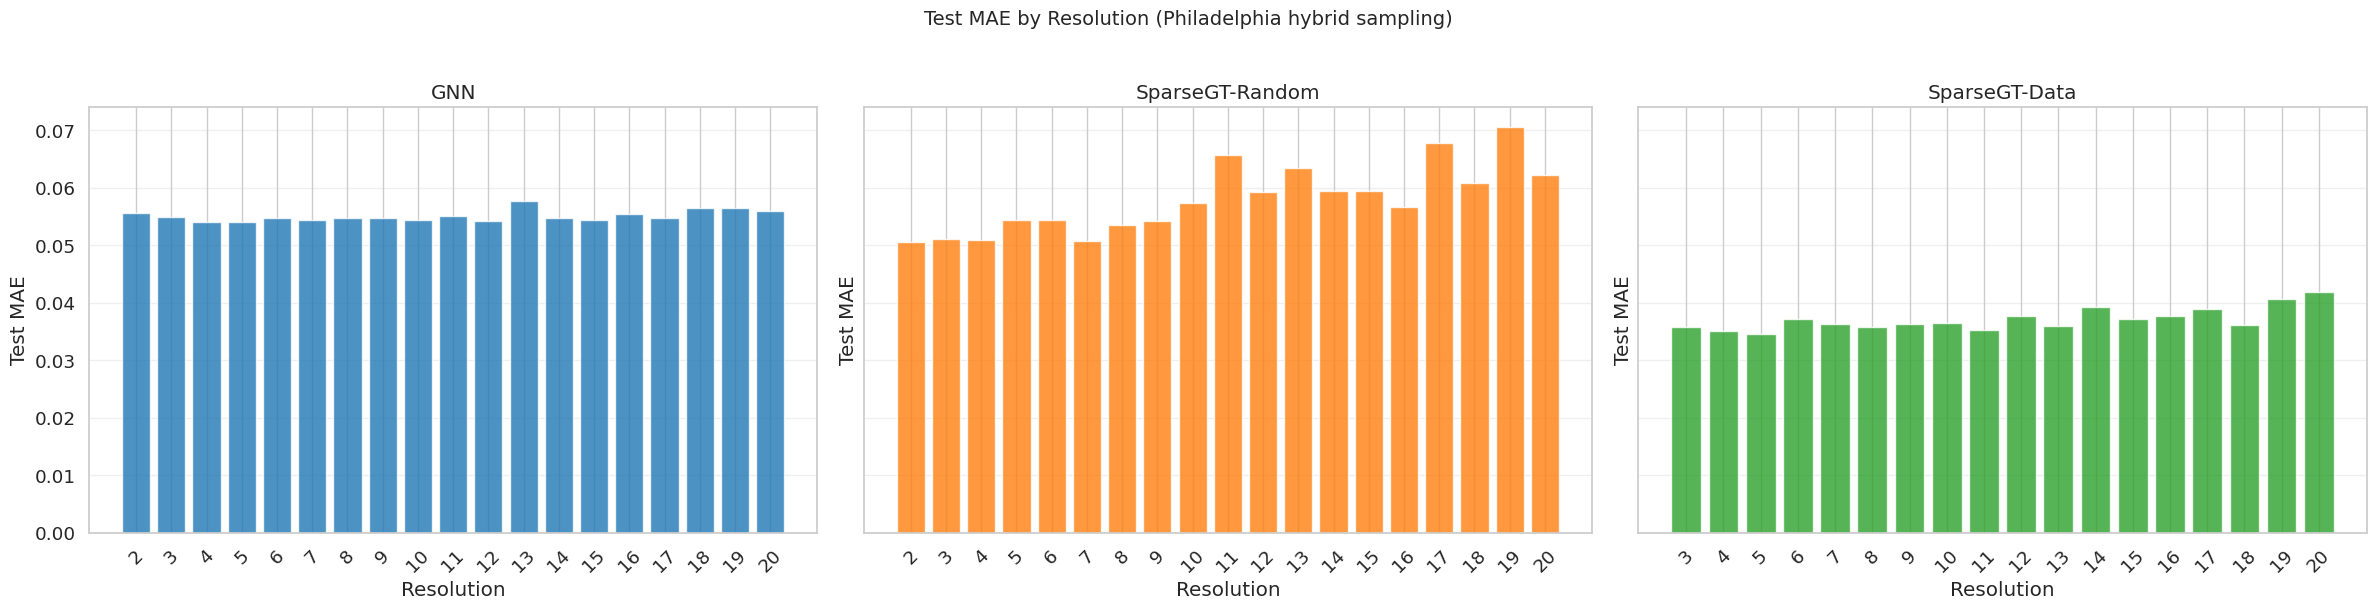

In [12]:
model_labels = ["GNN", "SparseGT-Random", "SparseGT-Data"]
present = [m for m in model_labels if m in best_per_resolution["model_label"].values]
fig, axes = plt.subplots(1, len(present), figsize=(8 * len(present), 6), sharey=True, squeeze=False)

for ax, label in zip(axes[0], present):
    sub = best_per_resolution[
        best_per_resolution["model_label"] == label
    ].sort_values("resolution")

    if sub.empty:
        ax.set_title(f"{label}: no data")
        continue

    ax.bar(sub["resolution"].astype(str), sub["test_mae"], color=COLOR_MAP[label], alpha=0.8)
    ax.set_xlabel("Resolution")
    ax.set_ylabel(ERROR_LABEL)
    ax.set_title(label)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Test MAE by Resolution (Philadelphia hybrid sampling)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Run status summary

In [13]:
print("=== e27 Philadelphia Hybrid Sampling Run Summary ===")
print(f"Total runs: {len(df)}")
print(f"\nBy state:")
print(df["state"].value_counts().to_string())
print(f"\nBy model_label:")
print(df["model_label"].value_counts().to_string())
print(f"\nResolutions covered: {sorted(df['resolution'].unique())}")
print(f"\nExpected resolutions (2-20): {list(range(2, 21))}")
missing = set(range(2, 21)) - set(df["resolution"].unique())
if missing:
    print(f"Missing resolutions (2-20): {sorted(missing)}")
else:
    print("All resolutions (2-20) present.")

=== e27 Philadelphia Hybrid Sampling Run Summary ===
Total runs: 60

By state:
state
finished    60

By model_label:
model_label
GNN                21
SparseGT-Random    21
SparseGT-Data      18

Resolutions covered: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]

Expected resolutions (2-20): [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
All resolutions (2-20) present.
